# 🏦 Loan Default Prediction — Full Pipeline
All 4 models, class weights, threshold optimization, feature engineering.

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, precision_recall_curve,
                              f1_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier




In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304417 entries, 0 to 307510
Columns: 103 entries, SK_ID_CURR to IS_HIGH_INCOME
dtypes: float64(46), int64(44), object(13)
memory usage: 241.5+ MB


In [23]:
df.sample(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,EXT_MEAN,EXT_MIN,EXT_MAX,EXT_PRODUCT,DOC_COUNT,CONTACT_SUM,DEF_30_RATIO,DEF_60_RATIO,BUREAU_TOTAL,IS_HIGH_INCOME
74798,186751,0,Cash loans,M,Y,Y,2,135000.0,225000.0,24363.0,...,0.404913,0.211551,0.598275,0.126565,1,5,0.0,0.0,2.0,0
62550,172544,0,Cash loans,F,Y,N,0,94500.0,215640.0,10372.5,...,0.283182,0.011417,0.554947,0.006336,1,3,0.0,0.0,1.0,0
285696,430884,0,Cash loans,M,N,Y,1,180000.0,343800.0,13090.5,...,0.618220,0.535276,0.701163,0.375316,1,4,0.0,0.0,1.0,1
192234,322907,0,Cash loans,F,Y,N,0,135000.0,884124.0,25848.0,...,0.377491,0.346624,0.408359,0.141547,1,5,0.0,0.0,6.0,0
284075,428988,0,Cash loans,F,N,N,0,135000.0,544491.0,17694.0,...,0.437057,0.158555,0.715558,0.113455,1,5,0.0,0.0,3.0,0


In [24]:
df.shape

(304417, 103)

In [25]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'EXT_MEAN', 'EXT_MIN', 'EXT_MAX', 'EXT_PRODUCT', 'DOC_COUNT',
       'CONTACT_SUM', 'DEF_30_RATIO', 'DEF_60_RATIO', 'BUREAU_TOTAL',
       'IS_HIGH_INCOME'],
      dtype='object', length=103)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304417 entries, 0 to 307510
Columns: 103 entries, SK_ID_CURR to IS_HIGH_INCOME
dtypes: float64(46), int64(44), object(13)
memory usage: 241.5+ MB


In [27]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,EXT_MEAN,EXT_MIN,EXT_MAX,EXT_PRODUCT,DOC_COUNT,CONTACT_SUM,DEF_30_RATIO,DEF_60_RATIO,BUREAU_TOTAL,IS_HIGH_INCOME
count,304417.000000,304417.000000,304417.000000,304417.000000,3.044170e+05,304417.000000,3.044170e+05,304417.000000,304417.000000,304417.000000,...,304417.000000,3.044170e+05,304417.000000,3.044170e+05,304417.000000,304417.000000,304417.000000,304417.000000,304417.000000,304417.000000
mean,278178.138133,0.080997,0.416163,162911.014841,5.937549e+05,26865.533924,5.332488e+05,0.020749,-16040.137936,64255.502584,...,0.514796,4.173012e-01,0.612290,2.681839e-01,0.930204,3.353045,0.041308,0.030457,2.280904,0.495321
std,102792.633280,0.272832,0.721311,77494.004409,3.966523e+05,14072.600477,3.633548e+05,0.013655,4371.754626,141638.808199,...,0.135365,1.770569e-01,0.128826,1.410952e-01,0.342625,0.865570,0.125729,0.109085,2.185972,0.499979
min,100002.000000,0.000000,0.000000,25650.000000,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000269,8.173617e-08,0.000527,5.239158e-09,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,189134.000000,0.000000,0.000000,112500.000000,2.700000e+05,16456.500000,2.385000e+05,0.010006,-19696.000000,-2754.000000,...,0.425483,2.830802e-01,0.535276,1.553836e-01,1.000000,3.000000,0.000000,0.000000,1.000000,0.000000
50%,278202.000000,0.000000,0.000000,144000.000000,5.094000e+05,24750.000000,4.500000e+05,0.018850,-15754.000000,-1207.000000,...,0.531786,4.494154e-01,0.629674,2.714577e-01,1.000000,3.000000,0.000000,0.000000,2.000000,0.000000
75%,367126.000000,0.000000,1.000000,202500.000000,8.086500e+05,34362.000000,6.795000e+05,0.028663,-12406.000000,-285.000000,...,0.615047,5.352763e-01,0.707176,3.712724e-01,1.000000,4.000000,0.000000,0.000000,3.000000,1.000000
max,456255.000000,1.000000,19.000000,469800.000000,4.050000e+06,225000.000000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,0.840552,8.125934e-01,0.896010,7.047654e-01,4.000000,6.000000,0.857143,0.857143,262.000000,1.000000


In [28]:
# Percentage of missing values
missing = df.isnull().sum() / len(df) * 100
missing = missing.sort_values(ascending=False)

print(missing.head(10))

SK_ID_CURR            0.0
TARGET                0.0
NAME_CONTRACT_TYPE    0.0
CODE_GENDER           0.0
FLAG_OWN_CAR          0.0
FLAG_OWN_REALTY       0.0
CNT_CHILDREN          0.0
AMT_INCOME_TOTAL      0.0
AMT_CREDIT            0.0
AMT_ANNUITY           0.0
dtype: float64


In [29]:
# Check target distribution
df['TARGET'].value_counts()

# Percentage
df['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
0,91.900255
1,8.099745


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

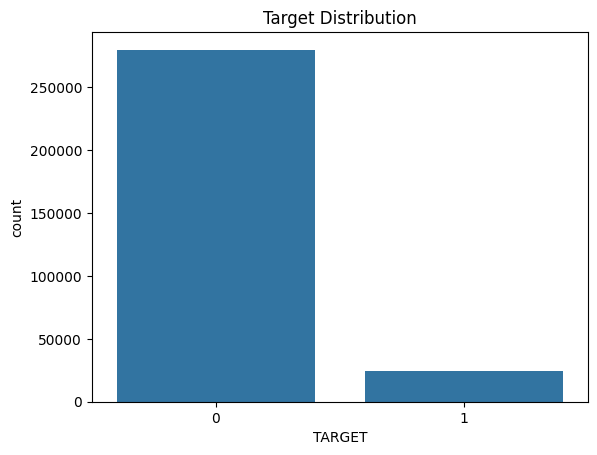

In [31]:
sns.countplot(x='TARGET', data=df)
plt.title("Target Distribution")
plt.show()

In [32]:
missing = df.isnull().sum()
missing = missing[missing > 0]

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
}).sort_values(by='Percentage', ascending=False)

missing_df.head(20)

,Missing Values,Percentage


In [33]:
# Drop columns with >50% missing
# Identify columns
cols_to_drop = missing_df[missing_df['Percentage'] > 50].index

# Keep only valid ones
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

# Drop safely
df.drop(columns=cols_to_drop, inplace=True)
# Fill remaining
for col in df.select_dtypes(include=['float64', 'int64']):
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']):
    df[col] = df[col].fillna(df[col].mode()[0])

In [34]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,EXT_MEAN,EXT_MIN,EXT_MAX,EXT_PRODUCT,DOC_COUNT,CONTACT_SUM,DEF_30_RATIO,DEF_60_RATIO,BUREAU_TOTAL,IS_HIGH_INCOME
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.201162,0.139376,0.262949,0.036649,1,4,0.666667,0.666667,1.0,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.578761,0.535276,0.622246,0.333073,1,4,0.000000,0.000000,0.0,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.642739,0.555912,0.729567,0.405575,0,5,0.000000,0.000000,0.0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.592859,0.535276,0.650442,0.348166,1,3,0.000000,0.000000,1.0,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.429007,0.322738,0.535276,0.172754,1,3,0.000000,0.000000,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.608454,0.535276,0.681632,0.364862,1,3,0.000000,0.000000,1.0,1
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.325634,0.115992,0.535276,0.062088,1,3,0.000000,0.000000,1.0,0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.377290,0.218859,0.535722,0.117248,1,4,0.000000,0.000000,3.0,1
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.587593,0.514163,0.661024,0.339874,1,3,0.000000,0.000000,0.0,1


In [35]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
len(num_cols)

90

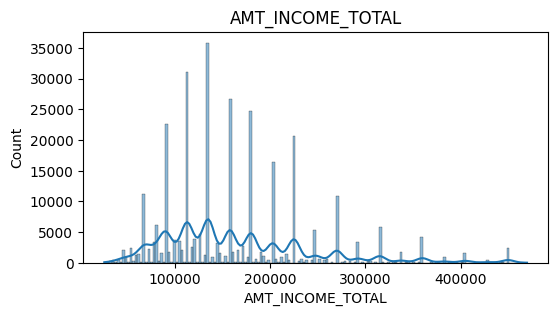

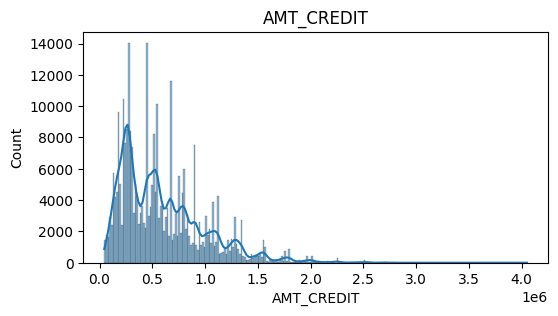

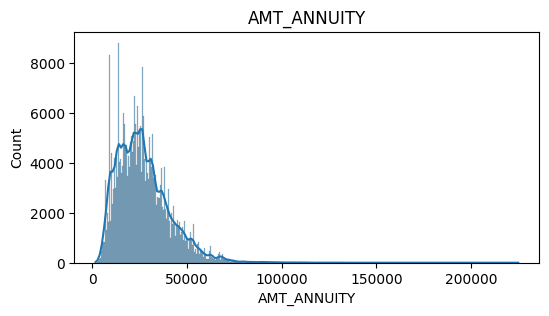

In [36]:
important_num = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

for col in important_num:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

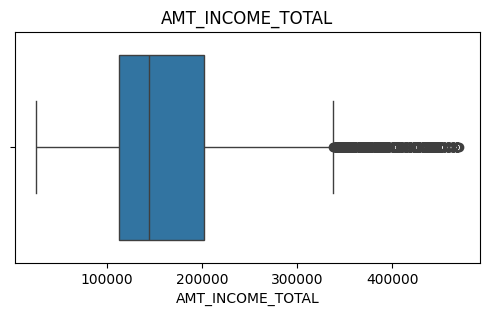

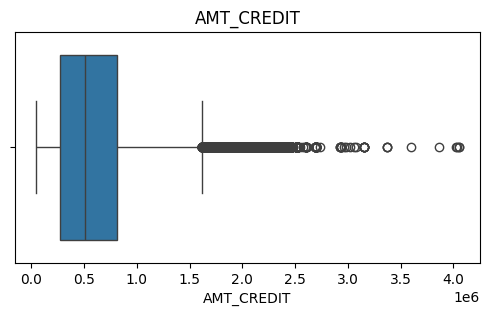

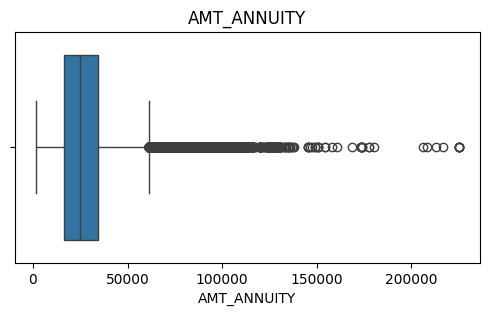

In [37]:
for col in important_num:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [38]:
cat_cols = df.select_dtypes(include=['object']).columns
len(cat_cols)

13

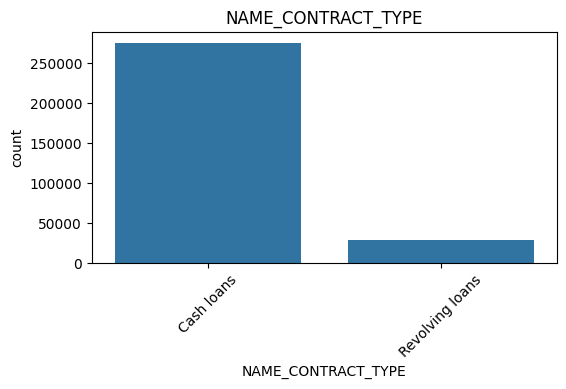

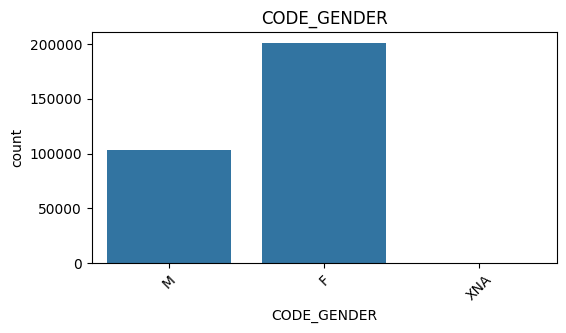

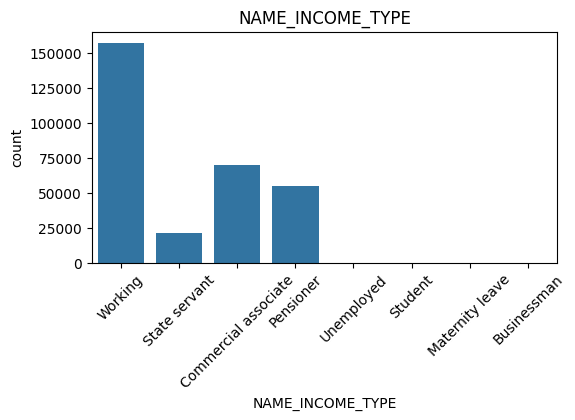

In [39]:
important_cat = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE']

for col in important_cat:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

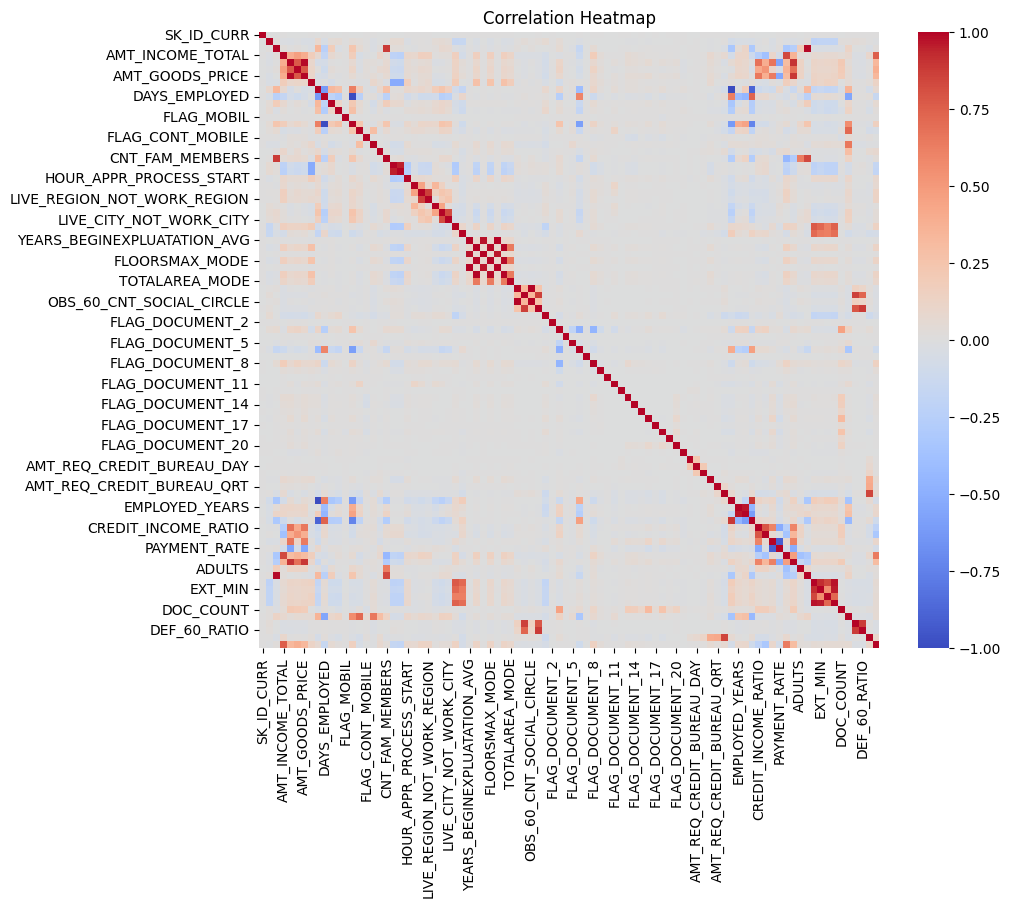

In [40]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [41]:
target_corr = corr['TARGET'].sort_values(ascending=False)
print(target_corr.head(10))
print(target_corr.tail(10))

TARGET                         1.000000
DAYS_BIRTH                     0.078653
REGION_RATING_CLIENT_W_CITY    0.060387
REGION_RATING_CLIENT           0.058407
DAYS_LAST_PHONE_CHANGE         0.055525
DAYS_ID_PUBLISH                0.051673
REG_CITY_NOT_WORK_CITY         0.050978
FLAG_EMP_PHONE                 0.046388
REG_CITY_NOT_LIVE_CITY         0.044556
FLAG_DOCUMENT_3                0.043959
Name: TARGET, dtype: float64
DAYS_EMPLOYED       -0.045341
EMPLOYED_YEARS      -0.045949
AGE_EMPLOYED_DIFF   -0.048080
AGE                 -0.078653
EXT_SOURCE_3        -0.156004
EXT_SOURCE_2        -0.160191
EXT_MAX             -0.187922
EXT_MIN             -0.189885
EXT_PRODUCT         -0.193829
EXT_MEAN            -0.213607
Name: TARGET, dtype: float64


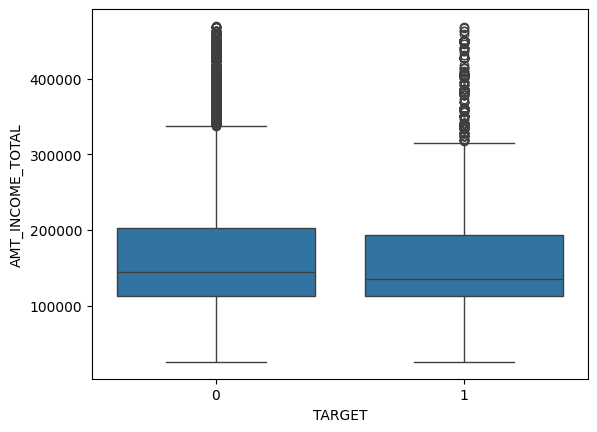

In [42]:
#Income vs Default
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)
plt.show()

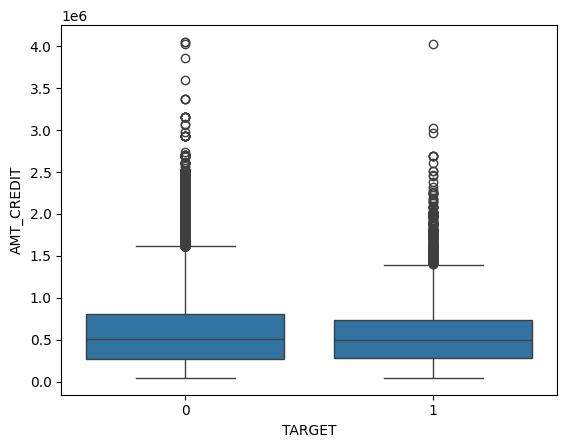

In [43]:
#Credit vs Default
sns.boxplot(x='TARGET', y='AMT_CREDIT', data=df)
plt.show()

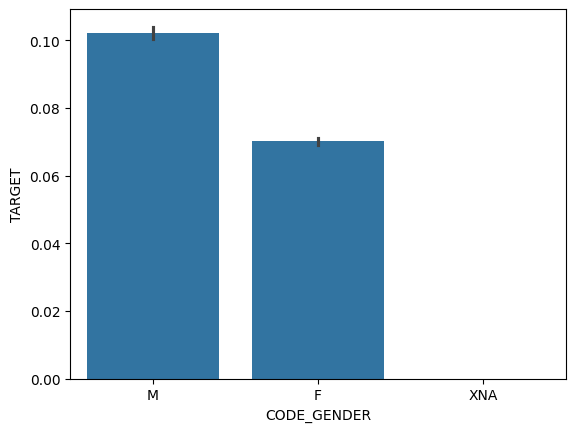

In [44]:
#Gender vs Default
sns.barplot(x='CODE_GENDER', y='TARGET', data=df)
plt.show()

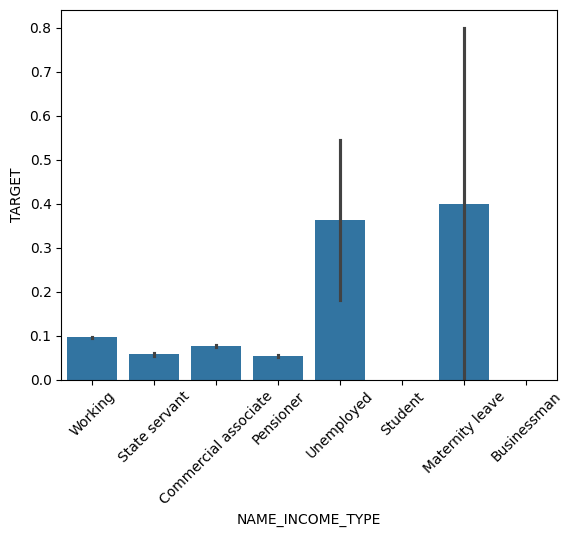

In [45]:
#Income Type vs Default
sns.barplot(x='NAME_INCOME_TYPE', y='TARGET', data=df)
plt.xticks(rotation=45)
plt.show()

In [46]:
df = df[df['AMT_INCOME_TOTAL'] < df['AMT_INCOME_TOTAL'].quantile(0.99)]

In [47]:
df.shape

(301262, 103)

## 1. Load Data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/application_train.csv')
print("Shape:", df.shape)
print("Target distribution:")
print(df['TARGET'].value_counts())
print()
print(f"Class imbalance ratio: {(df['TARGET']==0).sum() / (df['TARGET']==1).sum():.1f}:1")


Shape: (307511, 122)
Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Class imbalance ratio: 11.4:1


In [48]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,EXT_MEAN,EXT_MIN,EXT_MAX,EXT_PRODUCT,DOC_COUNT,CONTACT_SUM,DEF_30_RATIO,DEF_60_RATIO,BUREAU_TOTAL,IS_HIGH_INCOME
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.201162,0.139376,0.262949,0.036649,1,4,0.666667,0.666667,1.0,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.578761,0.535276,0.622246,0.333073,1,4,0.000000,0.000000,0.0,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.642739,0.555912,0.729567,0.405575,0,5,0.000000,0.000000,0.0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.592859,0.535276,0.650442,0.348166,1,3,0.000000,0.000000,1.0,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.429007,0.322738,0.535276,0.172754,1,3,0.000000,0.000000,0.0,0


## 2. Preprocessing — Missing Values & Column Drops

In [ ]:
# Drop columns with >50% missing
missing_pct = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} columns with >50% missing")

# Fill numeric with median, categorical with mode
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove extreme income outliers
df = df[df['AMT_INCOME_TOTAL'] < df['AMT_INCOME_TOTAL'].quantile(0.99)]
print(f"After cleaning shape: {df.shape}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")


Dropped 41 columns with >50% missing
After cleaning shape: (304417, 81)
Missing values remaining: 0


## 3. Feature Engineering

In [ ]:
# --- Age & Employment ---
df['AGE'] = df['DAYS_BIRTH'] / -365
df['EMPLOYED_YEARS'] = df['DAYS_EMPLOYED'].clip(upper=0) / -365  # fix positive anomaly
df['EMPLOYED_PERCENT'] = df['EMPLOYED_YEARS'] / (df['AGE'] + 1)
df['AGE_EMPLOYED_DIFF'] = df['AGE'] - df['EMPLOYED_YEARS']

# --- Credit & Income Ratios ---
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
df['CREDIT_TERM'] = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + 1)
df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)

# --- Family & Per-Person ---
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
df['CREDIT_PER_PERSON'] = df['AMT_CREDIT'] / (df['CNT_FAM_MEMBERS'] + 1)
df['ADULTS'] = df['CNT_FAM_MEMBERS'] - df['CNT_CHILDREN']
df['CHILD_TO_ADULT_RATIO'] = df['CNT_CHILDREN'] / (df['ADULTS'] + 1)

# --- External Scores (most predictive features!) ---
ext_cols = [c for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'] if c in df.columns]
print(f"External source columns available: {ext_cols}")
if len(ext_cols) >= 2:
    df['EXT_MEAN'] = df[ext_cols].mean(axis=1)
    df['EXT_MIN']  = df[ext_cols].min(axis=1)
    df['EXT_MAX']  = df[ext_cols].max(axis=1)
    df['EXT_PRODUCT'] = df[ext_cols].prod(axis=1)
    if len(ext_cols) == 3:
        df['EXT_STD'] = df[ext_cols].std(axis=1)

# --- Document & Contact Risk ---
doc_cols = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
df['DOC_COUNT'] = df[doc_cols].sum(axis=1)

contact_cols = [c for c in ['FLAG_MOBIL','FLAG_EMP_PHONE','FLAG_WORK_PHONE',
                              'FLAG_CONT_MOBILE','FLAG_PHONE','FLAG_EMAIL'] if c in df.columns]
df['CONTACT_SUM'] = df[contact_cols].sum(axis=1)

# --- Social Circle Risk ---
if 'DEF_30_CNT_SOCIAL_CIRCLE' in df.columns:
    df['DEF_30_RATIO'] = df['DEF_30_CNT_SOCIAL_CIRCLE'] / (df['OBS_30_CNT_SOCIAL_CIRCLE'] + 1)
    df['DEF_60_RATIO'] = df['DEF_60_CNT_SOCIAL_CIRCLE'] / (df['OBS_60_CNT_SOCIAL_CIRCLE'] + 1)

# --- Credit Bureau Requests ---
bureau_cols = [c for c in df.columns if 'AMT_REQ_CREDIT_BUREAU' in c]
if bureau_cols:
    df['BUREAU_TOTAL'] = df[bureau_cols].sum(axis=1)

# --- High Income Flag ---
df['IS_HIGH_INCOME'] = (df['AMT_INCOME_TOTAL'] > df['AMT_INCOME_TOTAL'].median()).astype(int)

# Fix infinities
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"Total features after engineering: {df.shape[1]}")


External source columns available: ['EXT_SOURCE_2', 'EXT_SOURCE_3']
Total features after engineering: 103


## 4. Prepare X, y — Encode & Split

In [ ]:
# Separate target
y = df['TARGET']
drop_cols = ['TARGET'] + [c for c in ['SK_ID_CURR'] if c in df.columns]
X = df.drop(columns=drop_cols)

# Label encode categoricals
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le
print(f"Encoded {len(cat_cols)} categorical columns")

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train target balance: {y_train.value_counts(normalize=True).to_dict()}")


Encoded 13 categorical columns
Train: (243533, 101) | Test: (60884, 101)
Train target balance: {0: 0.9190007103760065, 1: 0.08099928962399346}


## 5. Feature Scaling (for LR & DT)

In [ ]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols].fillna(0))
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols].fillna(0))

# For tree-based models (RF, XGB) — use unscaled, just fill NaN with -999
X_train_tree = X_train.fillna(-999)
X_test_tree  = X_test.fillna(-999)

# For LR — use scaled + fill NaN with 0 (already done above)
X_train_lr = X_train_scaled.fillna(0)
X_test_lr  = X_test_scaled.fillna(0)

# Imbalance ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")


scale_pos_weight for XGBoost: 11.35


## 6. Train All 4 Models

In [ ]:
# ============================================================
# MODEL 1: Logistic Regression
# ============================================================
print("Training Logistic Regression...")
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=3000,
    solver='saga',
    C=0.1,
    random_state=42
)
lr.fit(X_train_lr, y_train)
print("  ✓ Done")

# ============================================================
# MODEL 2: Decision Tree
# ============================================================
print("Training Decision Tree...")
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    min_samples_split=100,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train_tree, y_train)
print("  ✓ Done")

# ============================================================
# MODEL 3: Random Forest
# ============================================================
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_tree, y_train)
print("  ✓ Done")

# ============================================================
# MODEL 4: XGBoost
# ============================================================
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_tree, y_train)
print("  ✓ Done")


Training Logistic Regression...
  ✓ Done
Training Decision Tree...
  ✓ Done
Training Random Forest...
  ✓ Done
Training XGBoost...
  ✓ Done


## 7. Threshold Optimization & Evaluation


  Logistic Regression
  Optimal threshold (max F1): 0.675
              precision    recall  f1-score   support

    Approved       0.94      0.89      0.92     55953
   Defaulted       0.24      0.38      0.29      4931

    accuracy                           0.85     60884
   macro avg       0.59      0.64      0.60     60884
weighted avg       0.89      0.85      0.87     60884

  ROC-AUC Score : 0.7400


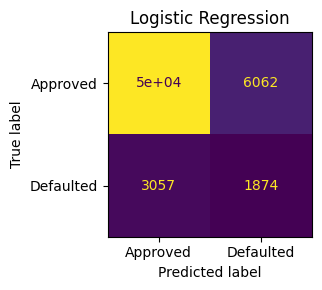


  Decision Tree
  Optimal threshold (max F1): 0.716
              precision    recall  f1-score   support

    Approved       0.94      0.90      0.92     55953
   Defaulted       0.23      0.34      0.27      4931

    accuracy                           0.85     60884
   macro avg       0.58      0.62      0.59     60884
weighted avg       0.88      0.85      0.87     60884

  ROC-AUC Score : 0.7141


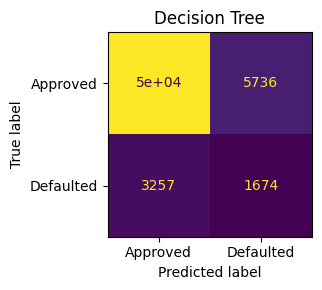


  Random Forest
  Optimal threshold (max F1): 0.605
              precision    recall  f1-score   support

    Approved       0.94      0.88      0.91     55953
   Defaulted       0.23      0.40      0.29      4931

    accuracy                           0.85     60884
   macro avg       0.59      0.64      0.60     60884
weighted avg       0.89      0.85      0.86     60884

  ROC-AUC Score : 0.7409


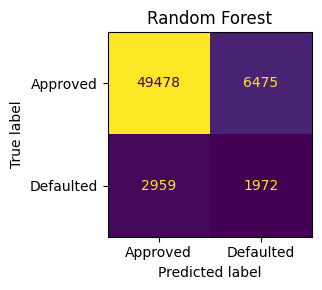


  XGBoost
  Optimal threshold (max F1): 0.652
              precision    recall  f1-score   support

    Approved       0.95      0.88      0.91     55953
   Defaulted       0.24      0.43      0.31      4931

    accuracy                           0.84     60884
   macro avg       0.59      0.66      0.61     60884
weighted avg       0.89      0.84      0.86     60884

  ROC-AUC Score : 0.7598


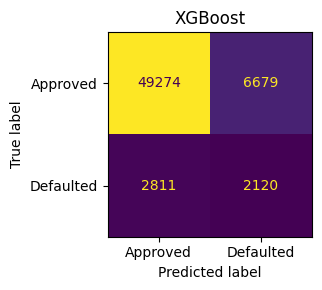

In [ ]:
def find_best_threshold(y_true, y_proba, strategy='f1'):
    """
    strategy='f1'        -> maximize F1 score (balanced)
    strategy='precision' -> find threshold where precision >= 0.35
    """
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_proba)
    if strategy == 'f1':
        f1 = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-8)
        best_idx = np.argmax(f1[:-1])  # exclude last point (no threshold)
        return thresholds[best_idx], f1[best_idx]
    elif strategy == 'precision':
        valid = np.where(precision_vals[:-1] >= 0.35)[0]
        if len(valid) == 0:
            return 0.5, None
        best_idx = valid[np.argmax(recall_vals[valid])]
        return thresholds[best_idx], None

def evaluate_model(name, y_true, y_proba, X_input):
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    # Find optimal threshold
    best_thresh, best_f1 = find_best_threshold(y_true, y_proba, strategy='f1')
    print(f"  Optimal threshold (max F1): {best_thresh:.3f}")

    y_pred = (y_proba >= best_thresh).astype(int)

    print(classification_report(y_true, y_pred, target_names=['Approved','Defaulted']))
    print(f"  ROC-AUC Score : {roc_auc_score(y_true, y_proba):.4f}")

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=['Approved','Defaulted']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}')
    plt.tight_layout()
    plt.show()

    return {
        'name': name,
        'threshold': best_thresh,
        'roc_auc': roc_auc_score(y_true, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

# ---- Evaluate all 4 models ----
results = {}

# LR uses scaled data
lr_proba = lr.predict_proba(X_test_lr)[:, 1]
results['LR'] = evaluate_model("Logistic Regression", y_test, lr_proba, X_test_lr)

# Tree-based use unscaled
dt_proba = dt.predict_proba(X_test_tree)[:, 1]
results['DT'] = evaluate_model("Decision Tree", y_test, dt_proba, X_test_tree)

rf_proba = rf.predict_proba(X_test_tree)[:, 1]
results['RF'] = evaluate_model("Random Forest", y_test, rf_proba, X_test_tree)

xgb_proba = xgb.predict_proba(X_test_tree)[:, 1]
results['XGB'] = evaluate_model("XGBoost", y_test, xgb_proba, X_test_tree)


## 8. ROC-AUC Comparison Plot

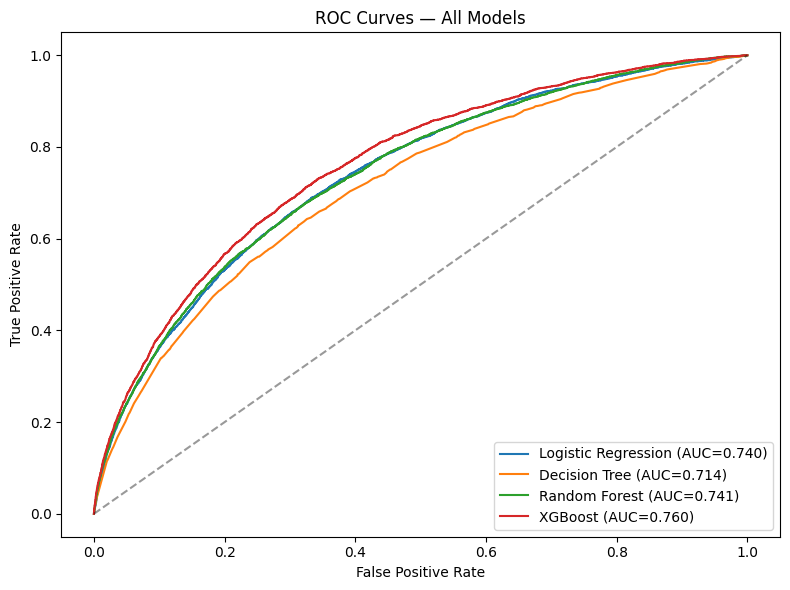

              Model  ROC-AUC  Threshold
Logistic Regression   0.7400      0.675
      Decision Tree   0.7141      0.716
      Random Forest   0.7409      0.605
            XGBoost   0.7598      0.652


In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for key, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{res['name']} (AUC={res['roc_auc']:.3f})")

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# AUC Summary Table
auc_df = pd.DataFrame([{
    'Model': r['name'],
    'ROC-AUC': round(r['roc_auc'], 4),
    'Threshold': round(r['threshold'], 3)
} for r in results.values()])
print(auc_df.to_string(index=False))


## 9. Voting Ensemble (Soft)

In [ ]:
# Average probabilities from all 4 models (soft ensemble)
ensemble_proba = (lr_proba + dt_proba + rf_proba + xgb_proba) / 4

print("\n" + "="*55)
print("  Voting Ensemble (Average of 4 models)")
print("="*55)

best_thresh, _ = find_best_threshold(y_test, ensemble_proba, strategy='f1')
y_pred_ens = (ensemble_proba >= best_thresh).astype(int)

print(f"  Optimal threshold: {best_thresh:.3f}")
print(classification_report(y_test, y_pred_ens, target_names=['Approved','Defaulted']))
print(f"  ROC-AUC: {roc_auc_score(y_test, ensemble_proba):.4f}")



  Voting Ensemble (Average of 4 models)
  Optimal threshold: 0.637
              precision    recall  f1-score   support

    Approved       0.94      0.88      0.91     55953
   Defaulted       0.24      0.41      0.30      4931

    accuracy                           0.84     60884
   macro avg       0.59      0.65      0.61     60884
weighted avg       0.89      0.84      0.86     60884

  ROC-AUC: 0.7494


## 10. XGBoost Feature Importance

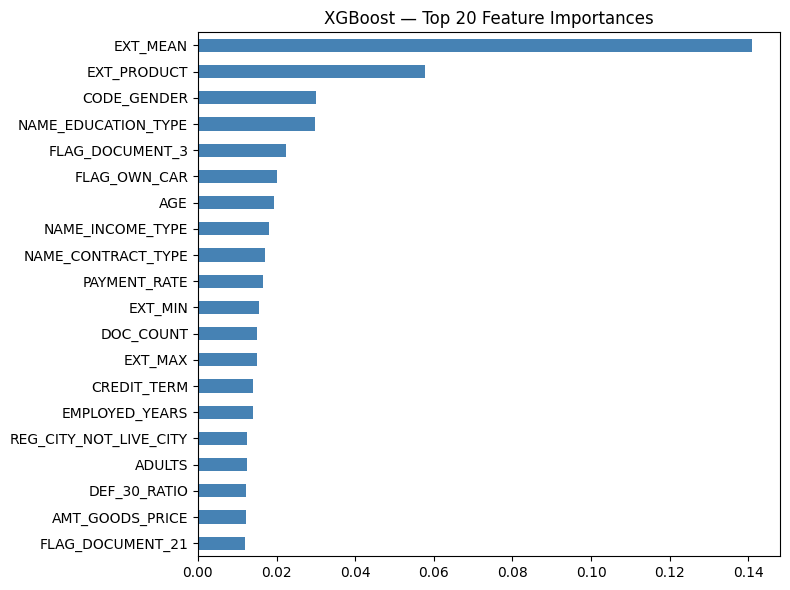


Top 10 features:
EXT_MEAN               0.140976
EXT_PRODUCT            0.057857
CODE_GENDER            0.030042
NAME_EDUCATION_TYPE    0.029800
FLAG_DOCUMENT_3        0.022539
FLAG_OWN_CAR           0.020157
AGE                    0.019253
NAME_INCOME_TYPE       0.018047
NAME_CONTRACT_TYPE     0.017192
PAYMENT_RATE           0.016478


In [ ]:
feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(8, 6))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title("XGBoost — Top 20 Feature Importances")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(top20.head(10).to_string())


## 11. Precision-Recall Curve (XGBoost)

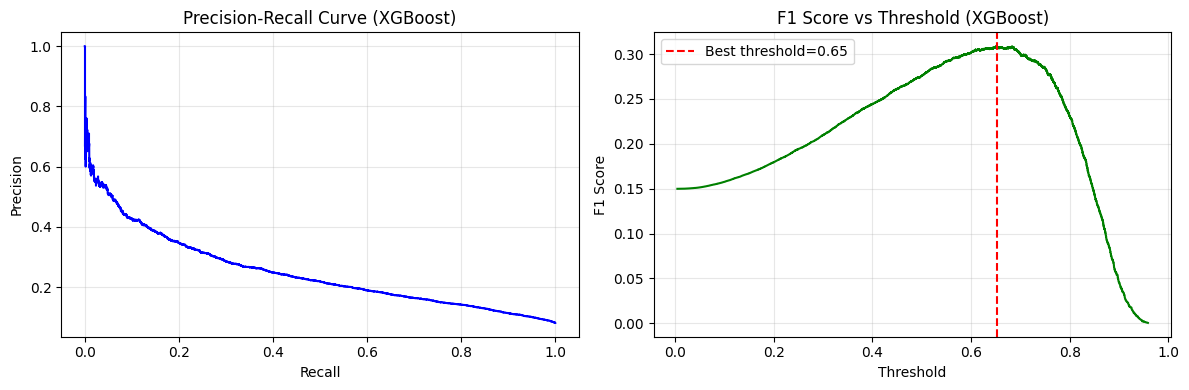

In [ ]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, xgb_proba)
f1_vals = 2 * precision_vals * recall_vals / (precision_vals + recall_vals + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PR Curve
axes[0].plot(recall_vals, precision_vals, color='blue')
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (XGBoost)")
axes[0].grid(True, alpha=0.3)

# F1 vs Threshold
axes[1].plot(thresholds, f1_vals[:-1], color='green')
best_idx = np.argmax(f1_vals[:-1])
axes[1].axvline(thresholds[best_idx], color='red', linestyle='--',
                label=f'Best threshold={thresholds[best_idx]:.2f}')
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Score vs Threshold (XGBoost)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 12. 3-Zone Loan Decision System (XGBoost)

=== Decision Counts ===
  Approve: 33,397 (54.9%)
  Review: 18,688 (30.7%)
  Reject: 8,799 (14.5%)

=== Decision vs Actual (Crosstab) ===
Decision  Approve  Reject  Review
Actual                           
0           32385    6679   16889
1            1012    2120    1799

=== Business Metrics ===
  Risky Approval Rate : 0.030 (lower is better)
  Reject Precision    : 0.241 (higher is better)


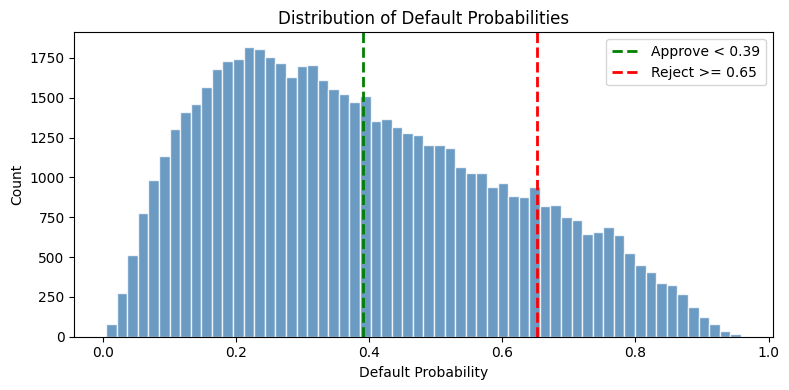

In [ ]:
# Tuned zones using optimal threshold from XGBoost
opt_thresh = results['XGB']['threshold']
approve_zone = opt_thresh * 0.6   # clearly low risk
reject_zone  = opt_thresh         # high risk

def loan_decision(prob):
    if prob >= reject_zone:
        return "Reject"
    elif prob >= approve_zone:
        return "Review"
    else:
        return "Approve"

decisions = [loan_decision(p) for p in xgb_proba]

results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Default_Probability': xgb_proba,
    'Decision': decisions
})

from collections import Counter
print("=== Decision Counts ===")
counts = Counter(decisions)
for k, v in counts.items():
    print(f"  {k}: {v:,} ({v/len(decisions)*100:.1f}%)")

print("\n=== Decision vs Actual (Crosstab) ===")
print(pd.crosstab(results_df['Actual'], results_df['Decision']))

# Business Metrics
approved_df = results_df[results_df['Decision'] == 'Approve']
risky_approved = (approved_df['Actual'] == 1).sum()
print(f"\n=== Business Metrics ===")
print(f"  Risky Approval Rate : {risky_approved / len(approved_df):.3f} (lower is better)")

rejected_df = results_df[results_df['Decision'] == 'Reject']
reject_precision = (rejected_df['Actual'] == 1).sum() / len(rejected_df) if len(rejected_df) > 0 else 0
print(f"  Reject Precision    : {reject_precision:.3f} (higher is better)")

# Probability histogram
plt.figure(figsize=(8, 4))
plt.hist(xgb_proba, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(approve_zone, color='green', linestyle='--', lw=2, label=f'Approve < {approve_zone:.2f}')
plt.axvline(reject_zone,  color='red',   linestyle='--', lw=2, label=f'Reject >= {reject_zone:.2f}')
plt.xlabel("Default Probability")
plt.ylabel("Count")
plt.title("Distribution of Default Probabilities")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Cross-Validation Summary (XGBoost)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("Running 5-fold Stratified Cross Validation on XGBoost...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    X_train_tree, y_train,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

print(f"\nCross-Validation ROC-AUC Scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")


Running 5-fold Stratified Cross Validation on XGBoost...

Cross-Validation ROC-AUC Scores: [0.76496861 0.75497378 0.75872113 0.75728461 0.76138255]
Mean: 0.7595 | Std: 0.0034
